In [1]:
from google.colab import files
uploaded = files.upload()

Saving sound_dataset.csv to sound_dataset.csv


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('sound_dataset.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nLabel distribution:")
print(df['label'].value_counts())

Dataset shape: (97, 5)

First 5 rows:
   avg  peak  variance  min  label
0    0     0         0    0      0
1    0     0         0    0      0
2    0     0         0    0      0
3    0     0         0    0      0
4    0     0         0    0      0

Label distribution:
label
0    74
1    23
Name: count, dtype: int64


In [3]:
import numpy as np

def augment_data(df, n_copies=5, noise_level=0.08):
    """
    Creates synthetic variations of each row by adding small random noise.
    n_copies = how many new versions to create per original row
    noise_level = how much variation (8% here)
    """
    augmented_rows = []

    for _, row in df.iterrows():
        # Keep the original row
        augmented_rows.append(row.values)

        # Create n_copies noisy versions
        for _ in range(n_copies):
            noisy_row = row.copy()
            for col in ['avg', 'peak', 'variance', 'min']:
                noise = np.random.normal(0, noise_level * (row[col] + 1))
                noisy_row[col] = max(0, row[col] + noise)  # never go below 0
            augmented_rows.append(noisy_row.values)

    new_df = pd.DataFrame(augmented_rows, columns=df.columns)
    new_df['label'] = new_df['label'].astype(int)
    return new_df

# Augment our dataset
augmented_df = augment_data(df, n_copies=5)

print("Original size:", len(df))
print("Augmented size:", len(augmented_df))
print("\nNew label distribution:")
print(augmented_df['label'].value_counts())

/tmp/ipykernel_960/2862803733.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.10122950669604369' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  noisy_row[col] = max(0, row[col] + noise)  # never go below 0
/tmp/ipykernel_960/2862803733.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.10215655438291585' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  noisy_row[col] = max(0, row[col] + noise)  # never go below 0
/tmp/ipykernel_960/2862803733.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.002539597937815819' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  noisy_row[col] = max(0, row[col] + noise)  # ne

Original size: 97
Augmented size: 582

New label distribution:
label
0    444
1    138
Name: count, dtype: int64


In [4]:
def augment_data(df, n_copies=5, noise_level=0.08):
    df = df.astype(float)  # convert all columns to float first
    augmented_rows = []

    for _, row in df.iterrows():
        augmented_rows.append(row.values)
        for _ in range(n_copies):
            noisy_row = row.copy()
            for col in ['avg', 'peak', 'variance', 'min']:
                noise = np.random.normal(0, noise_level * (row[col] + 1))
                noisy_row[col] = max(0, row[col] + noise)
            augmented_rows.append(noisy_row.values)

    new_df = pd.DataFrame(augmented_rows, columns=df.columns)
    new_df['label'] = new_df['label'].astype(int)
    return new_df

augmented_df = augment_data(df, n_copies=5)
print("Augmented size:", len(augmented_df))
print(augmented_df['label'].value_counts())

Augmented size: 582
label
0    444
1    138
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Separate normal and anomaly data
normal_data = augmented_df[augmented_df['label'] == 0][['avg', 'peak', 'variance', 'min']]
anomaly_data = augmented_df[augmented_df['label'] == 1][['avg', 'peak', 'variance', 'min']]

print("Normal samples:", len(normal_data))
print("Anomaly samples:", len(anomaly_data))

# Normalize using only normal data stats (important!)
scaler = MinMaxScaler()
normal_scaled = scaler.fit_transform(normal_data)

print("\nFirst 3 normalized normal samples:")
print(normal_scaled[:3])
print("\nMin value:", normal_scaled.min())
print("Max value:", normal_scaled.max())

Normal samples: 444
Anomaly samples: 138

First 3 normalized normal samples:
[[0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.00070811 0.         0.         0.69536278]]

Min value: 0.0
Max value: 1.0


In [6]:
import pandas as pd
df = pd.read_csv('sound_dataset.csv')

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build the autoencoder architecture
autoencoder = keras.Sequential([
    layers.Input(shape=(4,)),           # 4 inputs: avg, peak, variance, min
    layers.Dense(8, activation='relu'), # Encoder layer
    layers.Dense(2, activation='relu'), # Bottleneck - tiny squeeze!
    layers.Dense(8, activation='relu'), # Decoder layer
    layers.Dense(4, activation='sigmoid') # Output - 4 values, same as input
])

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118 (472.00 B)

 Trainable params: 118 (472.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the autoencoder ONLY on normal data
# Goal: input == output (it learns to reconstruct normal patterns)

history = autoencoder.fit(
    normal_scaled, normal_scaled,  # input and target are THE SAME (that's the trick!)
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2253 - val_loss: 0.2118
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2186 - val_loss: 0.2047
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2095 - val_loss: 0.1944
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1960 - val_loss: 0.1794
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1771 - val_loss: 0.1590
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1521 - val_loss: 0.1344
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1233 - val_loss: 0.1090
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0952 - val_loss: 0.0865
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0710 - val_loss: 0.0689
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0533 - val_loss: 0.0567
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0411 - val_loss: 0.0489
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

In [9]:
# First, scale anomaly data using the SAME scaler (fit on normal data)
anomaly_scaled = scaler.transform(anomaly_data)

# Get reconstruction error for both normal and anomaly data
normal_pred = autoencoder.predict(normal_scaled)
anomaly_pred = autoencoder.predict(anomaly_scaled)

# Calculate reconstruction error (MSE) for each sample
normal_errors = np.mean(np.square(normal_scaled - normal_pred), axis=1)
anomaly_errors = np.mean(np.square(anomaly_scaled - anomaly_pred), axis=1)

print("Normal data reconstruction error:")
print(f"  Mean: {normal_errors.mean():.4f}")
print(f"  Max:  {normal_errors.max():.4f}")

print("\nAnomaly data reconstruction error:")
print(f"  Mean: {anomaly_errors.mean():.4f}")
print(f"  Min:  {anomaly_errors.min():.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Normal data reconstruction error:
  Mean: 0.0022
  Max:  0.0731

Anomaly data reconstruction error:
  Mean: 2141.0551
  Min:  23.7415


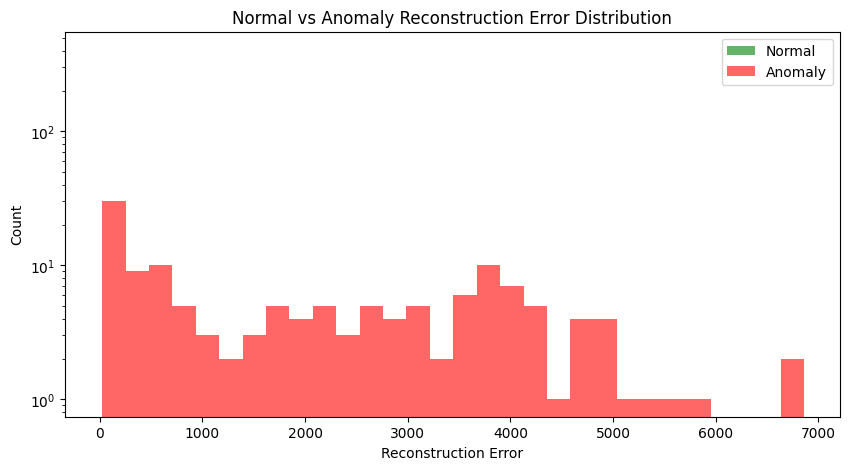

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(normal_errors, bins=30, alpha=0.6, label='Normal', color='green')
plt.hist(anomaly_errors, bins=30, alpha=0.6, label='Anomaly', color='red')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.title('Normal vs Anomaly Reconstruction Error Distribution')
plt.legend()
plt.yscale('log')  # log scale since anomaly errors are so much bigger
plt.show()

In [11]:
# Set threshold as a value between max normal error and min anomaly error
threshold = (normal_errors.max() + anomaly_errors.min()) / 2

print(f"Recommended threshold: {threshold:.4f}")
print(f"Max normal error:  {normal_errors.max():.4f}")
print(f"Min anomaly error: {anomaly_errors.min():.4f}")

# Test accuracy with this threshold
normal_correct = (normal_errors < threshold).sum()
anomaly_correct = (anomaly_errors >= threshold).sum()

total_correct = normal_correct + anomaly_correct
total_samples = len(normal_errors) + len(anomaly_errors)
accuracy = total_correct / total_samples * 100

print(f"\nAccuracy: {accuracy:.2f}%")
print(f"Normal correctly classified: {normal_correct}/{len(normal_errors)}")
print(f"Anomaly correctly classified: {anomaly_correct}/{len(anomaly_errors)}")

Recommended threshold: 11.9073
Max normal error:  0.0731
Min anomaly error: 23.7415

Accuracy: 100.00%
Normal correctly classified: 444/444
Anomaly correctly classified: 138/138


In [12]:
# Convert the trained model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(autoencoder)
tflite_model = converter.convert()

# Save it
with open('autoencoder.tflite', 'wb') as f:
    f.write(tflite_model)

import os
size_kb = os.path.getsize('autoencoder.tflite') / 1024
print(f"Model size: {size_kb:.2f} KB")


Saved artifact at '/tmp/tmp6y0dklof'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137066465289296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137066465290448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137066465289104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137066465287184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137066465291024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137066465287952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137066465291408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137066465290256: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model size: 2.85 KB


In [13]:
# Convert the .tflite file into a C header file
def convert_to_c_array(tflite_path, output_path, var_name="autoencoder_model"):
    with open(tflite_path, 'rb') as f:
        content = f.read()

    with open(output_path, 'w') as f:
        f.write(f'#ifndef {var_name.upper()}_H\n')
        f.write(f'#define {var_name.upper()}_H\n\n')
        f.write(f'const unsigned char {var_name}[] = {{\n')

        for i, byte in enumerate(content):
            f.write(f'0x{byte:02x}, ')
            if (i + 1) % 12 == 0:
                f.write('\n')

        f.write('\n};\n')
        f.write(f'const unsigned int {var_name}_len = {len(content)};\n\n')
        f.write('#endif\n')

    print(f"C array saved to {output_path}")
    print(f"Array size: {len(content)} bytes")

convert_to_c_array('autoencoder.tflite', 'model_data.h')

C array saved to model_data.h
Array size: 2916 bytes


In [14]:
from google.colab import files
files.download('model_data.h')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
print("Exact min/max values used for normalization:\n")
print("avg:      min =", scaler.data_min_[0], " max =", scaler.data_max_[0])
print("peak:     min =", scaler.data_min_[1], " max =", scaler.data_max_[1])
print("variance: min =", scaler.data_min_[2], " max =", scaler.data_max_[2])
print("min:      min =", scaler.data_min_[3], " max =", scaler.data_max_[3])

Exact min/max values used for normalization:

avg:      min = 0.0  max = 100.7037094909893
peak:     min = 0.0  max = 535.7100747593807
variance: min = 0.0  max = 17268.926565581904
min:      min = 0.0  max = 0.19454981230775495
